<a href="https://colab.research.google.com/github/tamaraebituatongha/learningquantitativeanalysis/blob/main/Quant_Metrics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📥 Downloading data for ['AAPL', 'TSLA']...

📊 PORTFOLIO CORRELATION REPORT
🤝 Correlation between AAPL and TSLA: 0.50


/tmp/ipykernel_2226/3627313117.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False)


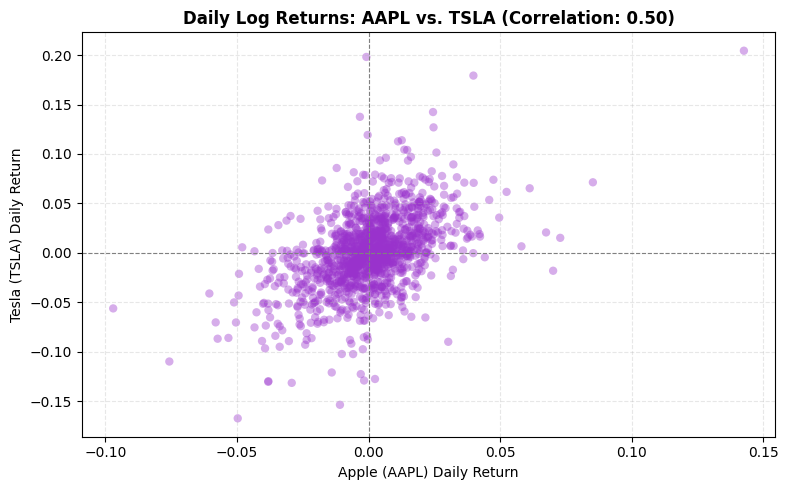

In [17]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 1. Choose two stocks with completely different business models
tickers = ["AAPL", "TSLA"]
start_date = "2021-01-01"
end_date = "2026-01-01"

print(f"Downloading data for {tickers}...")
raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# 2. Extract the Closing prices safely and build a clean table
df_prices = pd.DataFrame()
for ticker in tickers:
    if 'Close' in raw_data.columns:
        df_prices[ticker] = raw_data['Close'][ticker].squeeze()
    elif 'Adj Close' in raw_data.columns:
        df_prices[ticker] = raw_data['Adj Close'][ticker].squeeze()

# 3. Calculate Daily Log Returns for both stocks
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

# 4. Calculate the Correlation Matrix
correlation_matrix = df_returns.corr()
apple_tesla_corr = correlation_matrix.loc["AAPL", "TSLA"]

print("\n" + "="*40)
print(" PORTFOLIO CORRELATION REPORT")
print("="*40)
print(f"Correlation between AAPL and TSLA: {apple_tesla_corr:.2f}")
print("="*40)

# 5. Visualize the Relationship with a Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_returns['AAPL'], df_returns['TSLA'], alpha=0.4, color='darkorchid', edgecolors='none')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.title(f'Daily Log Returns: AAPL vs. TSLA (Correlation: {apple_tesla_corr:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Apple (AAPL) Daily Return', fontsize=10)
plt.ylabel('Tesla (TSLA) Daily Return', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Fetching historical data for TSLA...

QUANT METRICS REPORT FOR TSLA
Annualized Log Return:    12.35%
Annualized Volatility:    60.47%
Sharpe Ratio (Rf=4.0%): 0.14


/tmp/ipykernel_2226/1436865642.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker, start=start_date, end=end_date, progress=False)


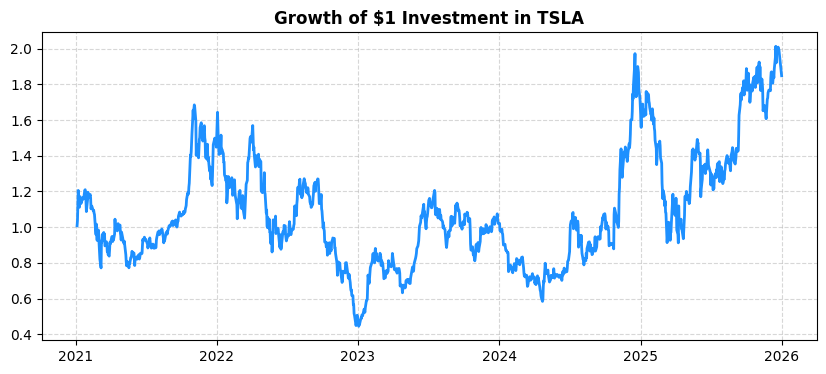

In [15]:
# 1. Install the finance data downloader directly into Colab
!pip install yfinance -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 2. Set our stock parameters
ticker = "TSLA"
start_date = "2021-01-01"
end_date = "2026-01-01"
risk_free_rate = 0.04

# 3. Download the historical data
print(f"Fetching historical data for {ticker}...")
raw_data = yf.download(ticker, start=start_date, end=end_date, progress=False)

# Clean up data structures for analysis (Handles multi-index and updated column formats)
df = pd.DataFrame()
if 'Close' in raw_data.columns:
    df['Close'] = raw_data['Close'].squeeze()
elif 'Adj Close' in raw_data.columns:
    df['Close'] = raw_data['Adj Close'].squeeze()
else:
    # If it is using a complex MultiIndex header, extract the ticker's closing prices safely
    df['Close'] = raw_data.xs('Close', axis=1, level=0).squeeze()

# 4. Calculate Daily Log Returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

# 5. Annualize return and volatility
avg_daily_return = df['Log_Return'].mean()
daily_volatility = df['Log_Return'].std()

annualized_return = avg_daily_return * 252
annualized_volatility = daily_volatility * np.sqrt(252)

# 6. Calculate the Sharpe Ratio
excess_return = annualized_return - risk_free_rate
sharpe_ratio = excess_return / annualized_volatility

# 7. Print the results
print("\n" + "="*40)
print(f"QUANT METRICS REPORT FOR {ticker}")
print("="*40)
print(f"Annualized Log Return:    {annualized_return:.2%}")
print(f"Annualized Volatility:    {annualized_volatility:.2%}")
print(f"Sharpe Ratio (Rf={risk_free_rate:.1%}): {sharpe_ratio:.2f}")
print("="*40)

# 8. Plot the cumulative growth
df['Cumulative_Growth'] = np.exp(df['Log_Return'].cumsum())
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Cumulative_Growth'], color='dodgerblue', lw=2)
plt.title(f'Growth of $1 Investment in {ticker}', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



In [16]:
!pip install yfinance
import yfinance as yf

# Download 1 month of daily data for Apple (AAPL)
data = yf.download("AAPL", period="1mo")

# Look at the data
print(data.head())

/tmp/ipykernel_2226/3475952459.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period="1mo")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-07-15  327.217804  328.446755  317.046583  317.346312  60957600
2026-07-16  332.972839  334.391599  326.508413  327.727363  62970600
2026-07-17  333.452393  334.701315  328.716487  331.693930  63407100
2026-07-20  326.308563  333.422423  323.401067  333.222613  53468000
2026-07-21  327.457581  329.315994  321.942348  322.851568  41338900
